In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from tqdm import tqdm

import Flexivan_Prediction_Package

In [4]:
# Get filenames from folder
print('Getting PAST raw data filenames...')
DATA_Folder = '/root/Flexivan/Flexivan/Daily prediction/DATA'

FILENAMES = [f for f in os.listdir(DATA_Folder) if os.path.isfile(os.path.join(DATA_Folder, f))]
selected = "Latest_Test_"
selected2 = '_DETAILED'
FILENAMES = [f for f in FILENAMES if selected in f and selected2 not in f]
DATES = Flexivan_Prediction_Package.extract_datetimes_from_filenames(FILENAMES)
Filenames_DF = pd.DataFrame({
    "Filenames": FILENAMES,
    "Dates": DATES
})
Filenames_DF_Sorted = Filenames_DF.sort_values(by='Dates')
FILENAMES = list(Filenames_DF_Sorted['Filenames'])
DATES = list(Filenames_DF_Sorted['Dates'])

print(f'DONE - {len(FILENAMES)} Filenames were found')


#endregion


Getting PAST raw data filenames...
DONE - 250 Filenames were found


In [5]:
DATA = pd.read_csv(f'{DATA_Folder}/{FILENAMES[0]}')
DATA.columns

Index(['CHS ID', 'CHS Pickup Loc', 'CHS Return Loc', 'CHS Pickup Date',
       'CHS Return Dt', 'CHS pickup MCO', 'CHS pickup MCO.1', 'Customer',
       'CTR Trip Pattern', 'DC Loc', 'CTR pick Dt', 'CTR Return Dt',
       'CTR Trip Hrs', 'CTR Pickup Term', 'CTR Return Term', 'CHS Trip Hrs',
       'CTR Trip Loc Type Pattern', 'On Street Count', 'Total CTR Trips'],
      dtype='object')

In [6]:
# Check the average 

PUs_Quants_per_Day_by_LOT = {}
Pickup_LOT_Field_Name = 'CHS Pickup Loc'

print(f'Collecting PUs quantities from all {len(FILENAMES)} data file per lot...')

for filename in tqdm(FILENAMES):
    DATA = pd.read_csv(f'{DATA_Folder}/{filename}')

    PU_Lots_Unique = list(DATA[Pickup_LOT_Field_Name].unique())

    for pu_lot in PU_Lots_Unique:
        DATA_TEMP = DATA[DATA[Pickup_LOT_Field_Name]==pu_lot]

        try:
            PUs_Quants_per_Day_by_LOT[pu_lot]
        except:
            PUs_Quants_per_Day_by_LOT[pu_lot] = []

        PUs_Quants_per_Day_by_LOT[pu_lot].append(len(DATA_TEMP))
    
print('DONE.')

100%|██████████| 250/250 [02:50<00:00,  1.46it/s]

DONE.


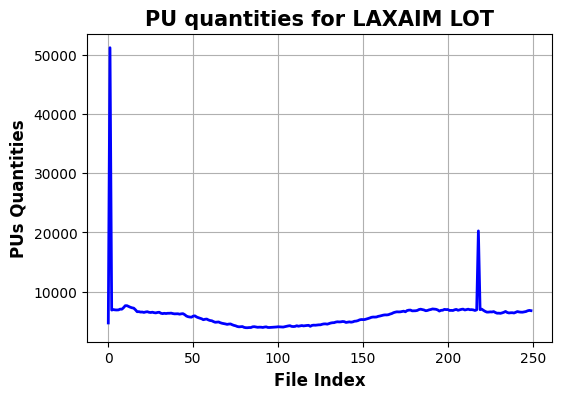

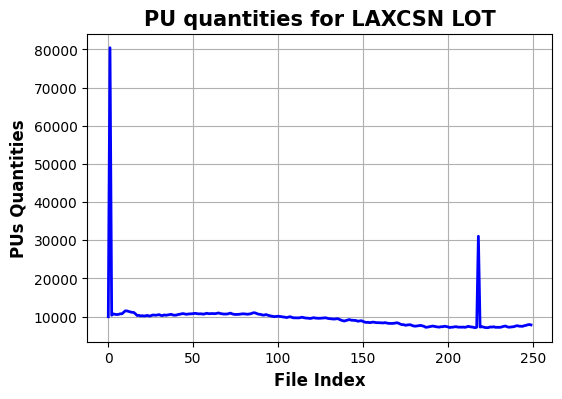

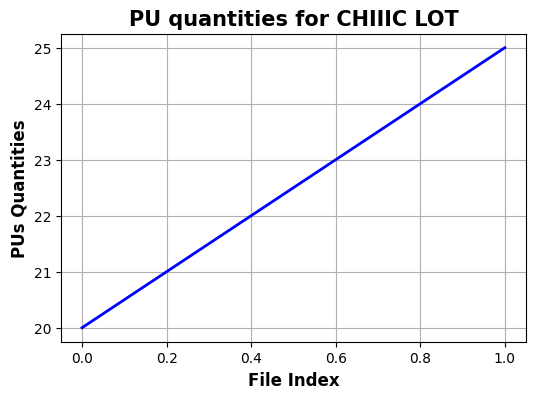

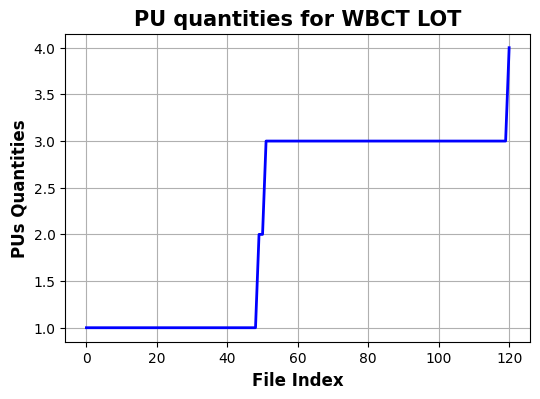

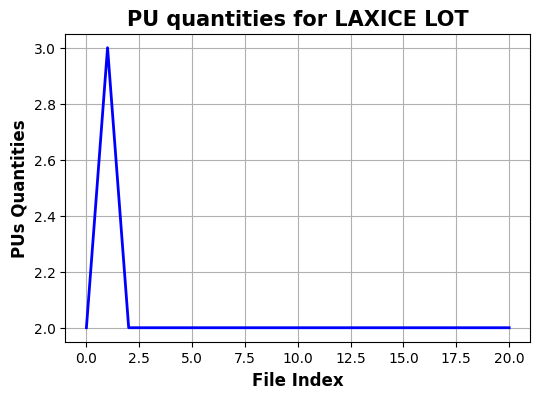

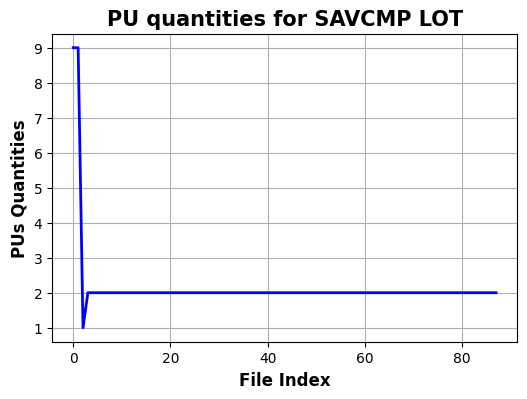

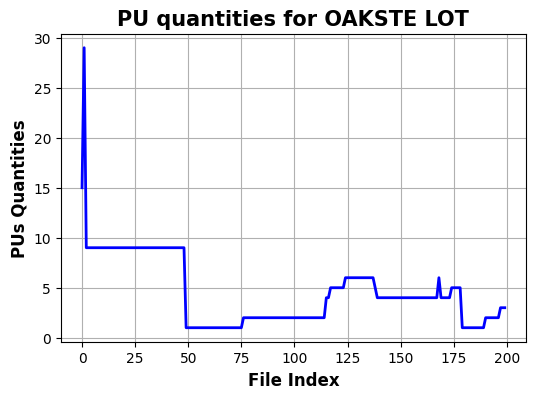

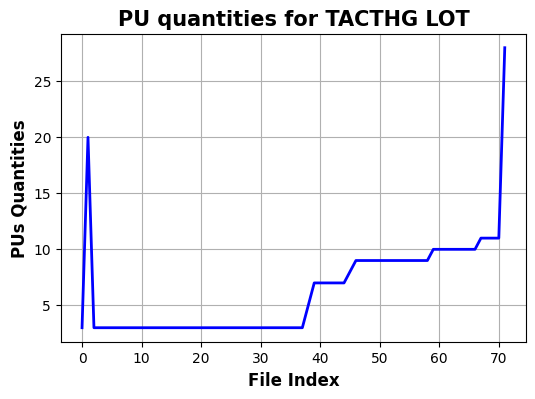

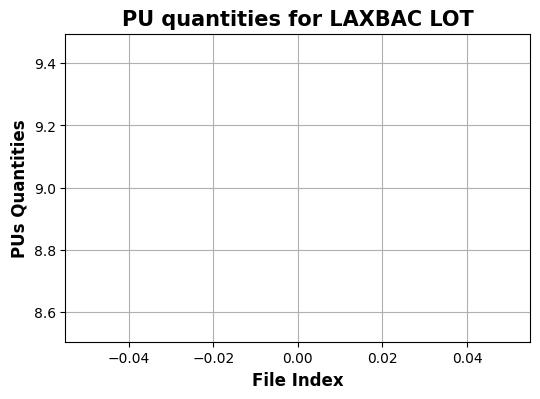

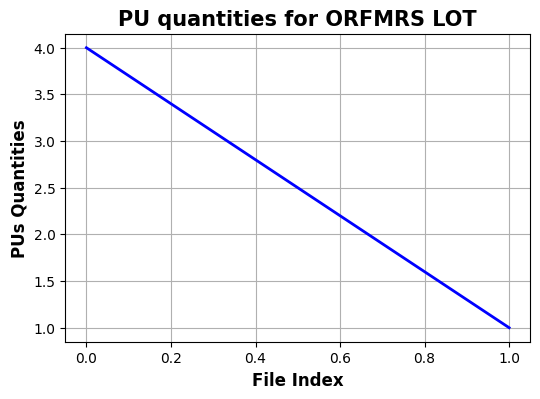

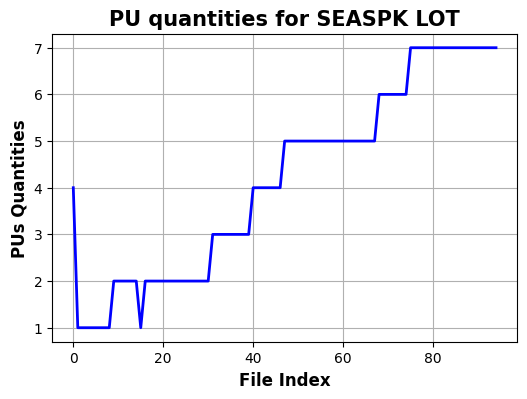

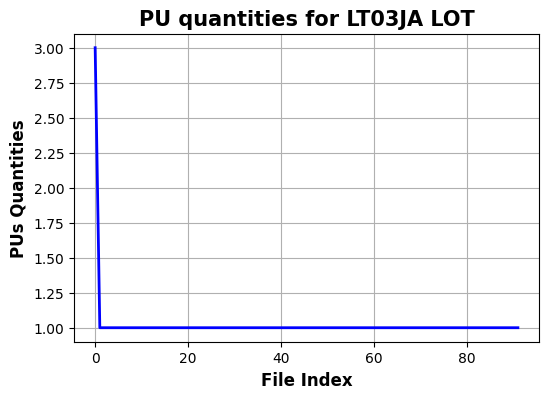

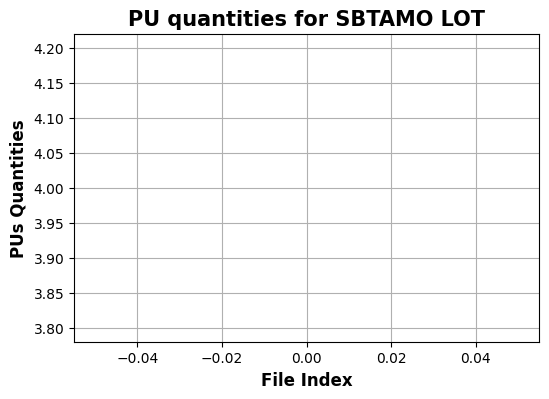

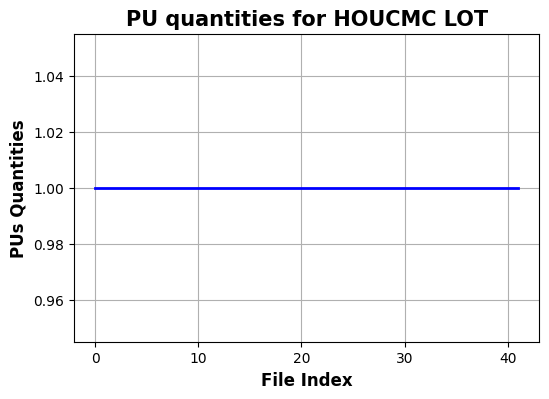

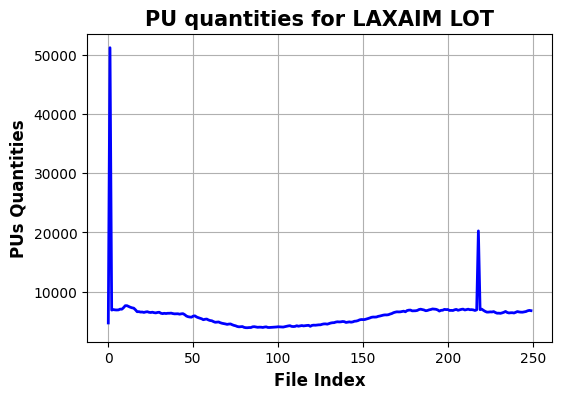

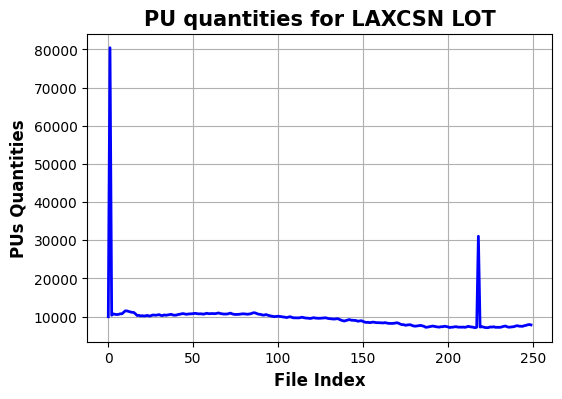

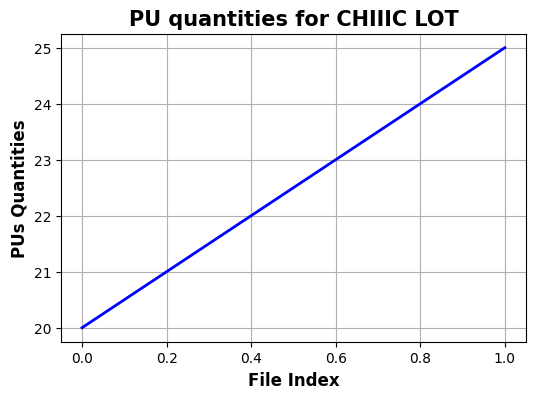

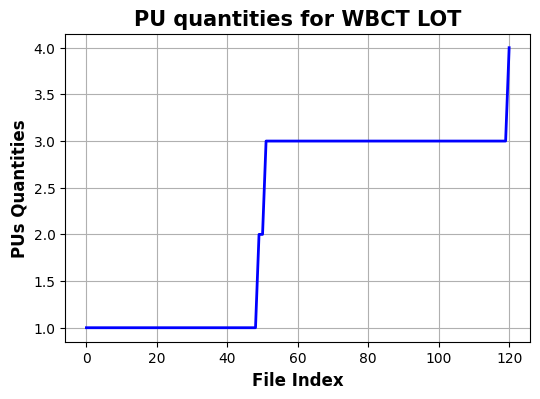

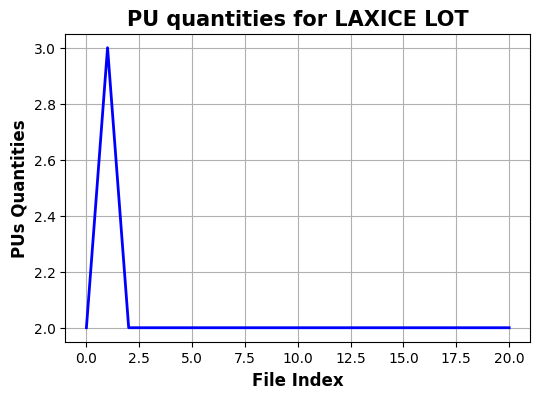

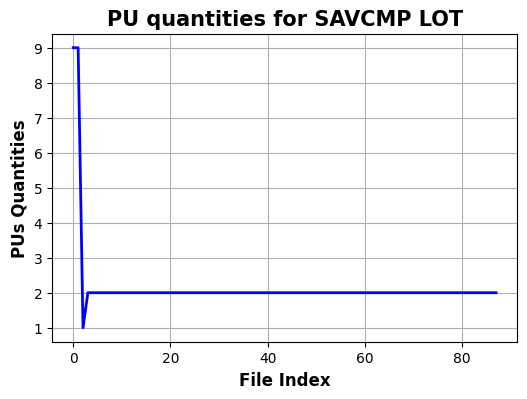

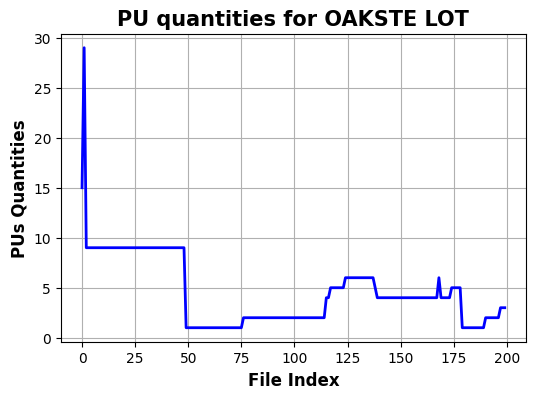

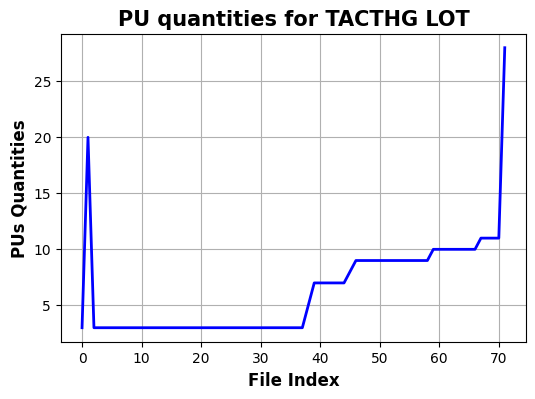

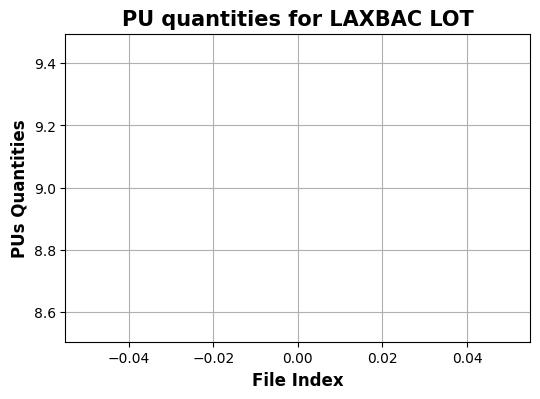

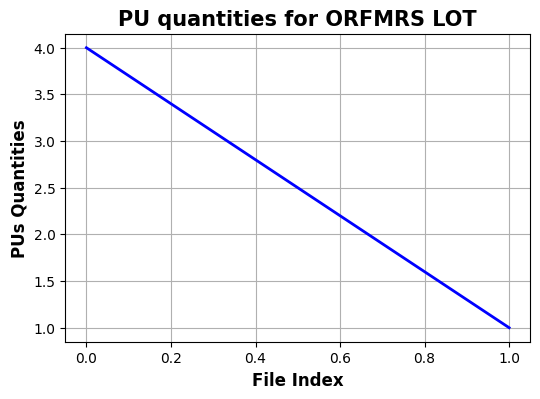

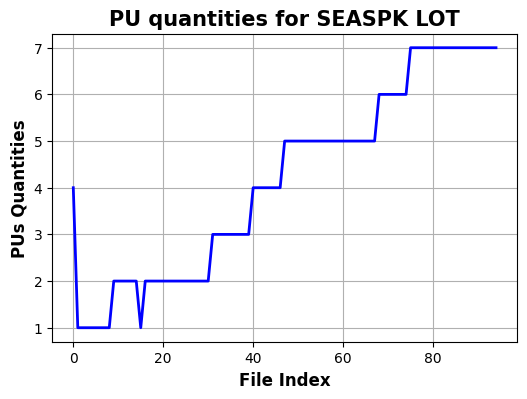

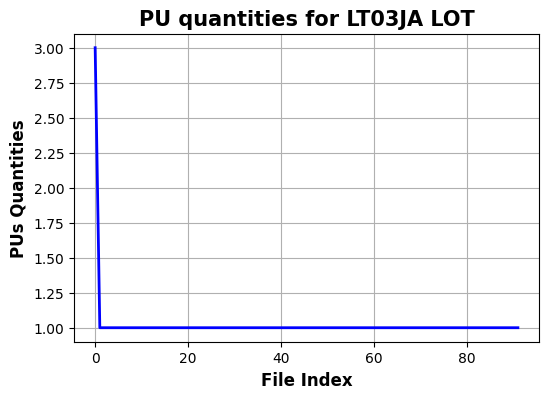

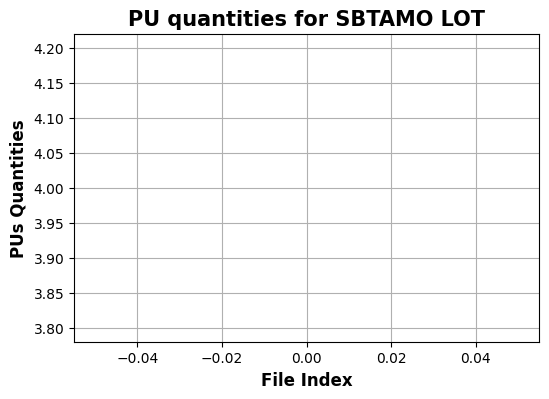

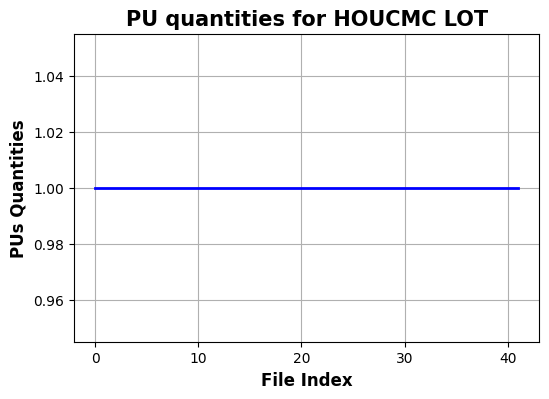

In [8]:
# Analyze results

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

for pu_lot in PUs_Quants_per_Day_by_LOT.keys():
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(np.arange(0, len(PUs_Quants_per_Day_by_LOT[pu_lot])), PUs_Quants_per_Day_by_LOT[pu_lot], color='b', linewidth=2)
    ax.set_xlabel('File Index', fontsize=12, fontweight='bold')
    ax.set_ylabel('PUs Quantities', fontsize=12, fontweight='bold')
    ax.set_title(f'PU quantities for {pu_lot} LOT', fontsize=15, fontweight='bold')
    ax.grid()

    plt.show()

In [ ]:
# Evaluate moving average accuracy (plot on plot)

In [ ]:
# Evaluate moving extrapolation accuracy (plot on plot)